theta=0  → F=1.000000, p_succ=1.000000
theta=π  → F=0.056847, p_succ=1.000000
max F=1.000000 at theta=0.0000
min F=0.056847 at theta=3.1416


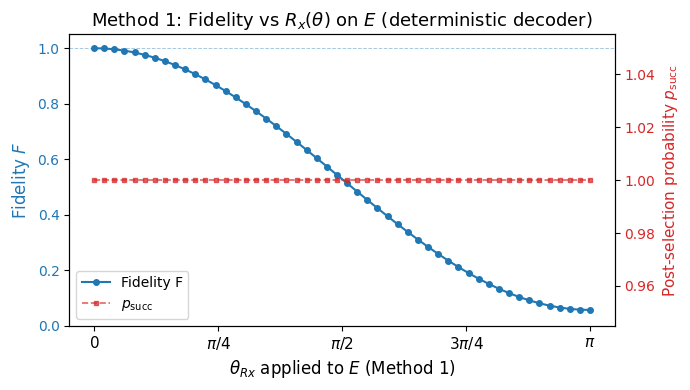

Saved.


In [1]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, state_fidelity
from math import pi
import numpy as np
import matplotlib.pyplot as plt


def input_message_state(theta_msg=2.5349076035276403, varphi_msg=2.0022404587009195):
    qc = QuantumCircuit(1)
    qc.u(theta_msg, varphi_msg, 0.0, 0)
    return Statevector.from_instruction(qc)


def build_deterministic_decoder(theta_rx,
                                  theta_msg=2.5349076035276403,
                                  varphi_msg=2.0022404587009195):
    C = QuantumRegister(1, 'C')
    E = QuantumRegister(1, 'E')
    R = QuantumRegister(1, 'R')
    G = QuantumRegister(1, 'G')
    M = QuantumRegister(1, 'M')
    A = QuantumRegister(1, 'A')
    Y = QuantumRegister(1, 'Y')
    qc = QuantumCircuit(C, E, R, G, M, A, Y)

    # 1) Prepare message state on M
    qc.u(theta_msg, varphi_msg, 0.0, M[0])

    # 2) SWAP message into C
    qc.swap(C[0], M[0])
    qc.barrier()

    # 3) Create Bell pairs
    qc.h(E[0])
    qc.cx(E[0], M[0])
    qc.h(R[0])
    qc.cx(R[0], G[0])
    qc.h(A[0])
    qc.cx(A[0], Y[0])
    qc.barrier()

    # 4) 1st Method perturbation: RX(theta_rx) on E
    qc.rx(theta_rx, E[0])
    qc.barrier()

    # 5) Scrambling Unitary
    qc.cz(C[0], R[0])
    qc.cz(E[0], R[0])
    qc.cz(C[0], E[0])
    qc.h(C[0])
    qc.h(E[0])
    qc.h(R[0])
    qc.cz(C[0], R[0])
    qc.cz(C[0], E[0])
    qc.cz(E[0], R[0])
    qc.barrier()

    # 6) Deterministic Decoder – Unitary Conjugate
    qc.cz(A[0], G[0])
    qc.cz(M[0], A[0])
    qc.cz(G[0], M[0])
    qc.h(A[0])
    qc.h(M[0])
    qc.h(G[0])
    qc.cz(A[0], G[0])
    qc.cz(G[0], M[0])
    qc.cz(M[0], A[0])
    qc.barrier()

    # 7) Grover operator (R, G)
    qc.rz(pi, R[0])
    qc.rx(pi, R[0])
    qc.rx(pi, G[0])
    qc.swap(R[0], G[0])
    qc.rz(pi, R[0])
    qc.barrier()

    # 8) Unitary Transpose
    qc.cz(A[0], G[0])
    qc.cz(M[0], A[0])
    qc.cz(G[0], M[0])
    qc.h(A[0])
    qc.h(M[0])
    qc.h(G[0])
    qc.cz(A[0], G[0])
    qc.cz(G[0], M[0])
    qc.cz(M[0], A[0])
    qc.barrier()

    # 9) Grover operator (A, Y)
    qc.rz(pi, A[0])
    qc.rx(pi, A[0])
    qc.rx(pi, Y[0])
    qc.swap(A[0], Y[0])
    qc.rz(pi, A[0])
    qc.barrier()

    # 10) Unitary Conjugate again
    qc.cz(A[0], G[0])
    qc.cz(M[0], A[0])
    qc.cz(G[0], M[0])
    qc.h(A[0])
    qc.h(M[0])
    qc.h(G[0])
    qc.cz(A[0], G[0])
    qc.cz(G[0], M[0])
    qc.cz(M[0], A[0])
    qc.barrier()

    # 11) Grover operator (R, G) again
    qc.rz(pi, R[0])
    qc.rx(pi, R[0])
    qc.rx(pi, G[0])
    qc.swap(R[0], G[0])
    qc.rz(pi, R[0])
    qc.barrier()

    # 12) Bell Projection unitary part
    qc.cx(R[0], G[0])
    qc.h(R[0])
    qc.barrier()

    return qc


def postselect_RG_00(psi):
    """
    Post-select on R=0, G=0.
    Register order: C=q0, E=q1, R=q2, G=q3, M=q4, A=q5, Y=q6
    Bit k of index i → qubit k (LSB convention).
    """
    data = psi.data.copy()
    new_data = np.zeros_like(data, dtype=complex)

    for i in range(len(data)):
        R_bit = (i >> 2) & 1
        G_bit = (i >> 3) & 1
        if R_bit == 0 and G_bit == 0:
            new_data[i] = data[i]

    norm = np.linalg.norm(new_data)
    if norm == 0:
        return None, 0.0
    new_data /= norm
    return Statevector(new_data), norm**2


def reduced_state_on_Y_after_postselection(theta_rx,
                                            theta_msg=2.5349076035276403,
                                            varphi_msg=2.0022404587009195):
    qc = build_deterministic_decoder(theta_rx, theta_msg, varphi_msg)
    psi_out = Statevector.from_instruction(qc)
    psi_post, p_succ = postselect_RG_00(psi_out)
    if psi_post is None:
        return None, p_succ
    rho_full = DensityMatrix(psi_post)
    # Keep only Y (qubit 6); trace out qubits 0-5
    rho_Y = partial_trace(rho_full, [0, 1, 2, 3, 4, 5])
    return rho_Y, p_succ


def fidelity_for_theta(theta_rx,
                        theta_msg=2.5349076035276403,
                        varphi_msg=2.0022404587009195):
    rho_Y, p_succ = reduced_state_on_Y_after_postselection(theta_rx, theta_msg, varphi_msg)
    if rho_Y is None:
        return 0.0, p_succ
    psi_in = input_message_state(theta_msg, varphi_msg)
    F = state_fidelity(rho_Y, psi_in)
    return F, p_succ


def sweep_thetas(num_points=50,
                  theta_min=0.0,
                  theta_max=np.pi,
                  theta_msg=2.5349076035276403,
                  varphi_msg=2.0022404587009195):
    thetas = np.linspace(theta_min, theta_max, num_points)
    fidelities, probs = [], []
    for theta_rx in thetas:
        F, p_succ = fidelity_for_theta(theta_rx, theta_msg, varphi_msg)
        fidelities.append(F)
        probs.append(p_succ)
    return thetas, np.array(fidelities), np.array(probs)


# ── Run ──────────────────────────────────────────────────────────────────────
thetas, fidelities, probs = sweep_thetas(num_points=50, theta_min=0.0, theta_max=np.pi)

# Quick diagnostic prints
print(f"theta=0  → F={fidelities[0]:.6f}, p_succ={probs[0]:.6f}")
print(f"theta=π  → F={fidelities[-1]:.6f}, p_succ={probs[-1]:.6f}")
print(f"max F={fidelities.max():.6f} at theta={thetas[np.argmax(fidelities)]:.4f}")
print(f"min F={fidelities.min():.6f} at theta={thetas[np.argmin(fidelities)]:.4f}")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(7, 4))

color_F = '#1f77b4'
color_p = '#d62728'

ax1.plot(thetas, fidelities, marker='o', markersize=4, color=color_F, label='Fidelity F')
ax1.set_xlabel(r'$\theta_{Rx}$ applied to $E$ (Method 1)', fontsize=12)

# π-labeled x-axis
tick_vals = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
tick_labels = [r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$']
ax1.set_xticks(tick_vals)
ax1.set_xticklabels(tick_labels, fontsize=11)
ax1.set_ylabel('Fidelity $F$', fontsize=12, color=color_F)
ax1.tick_params(axis='y', labelcolor=color_F)
ax1.set_ylim(0, 1.05)
ax1.axhline(1.0, color=color_F, lw=0.7, ls='--', alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(thetas, probs, marker='s', markersize=3, lw=1.2,
         color=color_p, ls='--', alpha=0.7, label='$p_{\\mathrm{succ}}$')
ax2.set_ylabel('Post-selection probability $p_{\\mathrm{succ}}$', fontsize=11, color=color_p)
ax2.tick_params(axis='y', labelcolor=color_p)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=10)

plt.title('Method 1: Fidelity vs $R_x(\\theta)$ on $E$ (deterministic decoder)', fontsize=13)
plt.tight_layout()
plt.savefig('fidelityvstheta_method1.pdf', dpi=300)
plt.show()
print("Saved.")

In [2]:
import numpy as np

theta_msg = 2.5349076035276403
varphi_msg = 2.0022404587009195

nx = np.sin(theta_msg) * np.cos(varphi_msg)
ny = np.sin(theta_msg) * np.sin(varphi_msg)
nz = np.cos(theta_msg)
nx2 = nx**2  # projection onto X axis squared

print(f"(n̂·x̂)² = {nx2:.6f}")
print(f"Predicted F(π) = {nx2:.6f}")
print(f"Measured  F(π) = 0.056847")

# Overlay on sweep
F_pred = np.cos(thetas/2)**2 + nx2 * np.sin(thetas/2)**2
print(f"max |F_sim - F_pred| = {np.max(np.abs(fidelities - F_pred)):.2e}")

(n̂·x̂)² = 0.056847
Predicted F(π) = 0.056847
Measured  F(π) = 0.056847
max |F_sim - F_pred| = 5.55e-16
